In [ ]:
"""
from google.colab import drive
drive.mount('/content/drive')
"""

Mounted at /content/drive


In [1]:
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import random
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class MFNetDataset(Dataset):
    def __init__(self, base_path, split_list, transform=None, mode='train', drop_prob=0):
        self.img_dir = os.path.join(base_path, "images")
        self.mask_dir = os.path.join(base_path, "labels")
        self.transform = transform
        self.mode = mode
        self.drop_prob = drop_prob

        if isinstance(split_list, str) and split_list.endswith('.txt'):
            with open(split_list, 'r') as f:
                self.common_names = [line.strip().replace('.png', '') for line in f.readlines()]
        elif isinstance(split_list, list):
            self.common_names = split_list

        self.common_names = [name for name in self.common_names if name]
        print(f"Dataset inizializzato in modalità '{self.mode}': {len(self.common_names)} immagini.")

    def __len__(self):
        return len(self.common_names)

    def __getitem__(self, idx):
        base_name = self.common_names[idx]

        # Load images
        img_rgba = Image.open(os.path.join(self.img_dir, base_name + ".png"))
        img_visual = img_rgba.convert('RGB')
        img_thermal = img_rgba.getchannel('A').convert('RGB')
        img_mask = Image.open(os.path.join(self.mask_dir, base_name + ".png")).convert('L')

        # Conversion to tensors
        if self.transform:
            tensor_visual = self.transform(img_visual)
            tensor_thermal = self.transform(img_thermal)
        else:
            # If there is no transform to apply
            tensor_visual = TF.to_tensor(img_visual)
            tensor_thermal = TF.to_tensor(img_thermal)

        tensor_mask = torch.as_tensor(np.array(img_mask), dtype=torch.long)

        # Data augmentation
        if self.mode == 'train':

            # Random Horizontal Flip
            if random.random() > 0.5:
                tensor_visual = torch.flip(tensor_visual, dims=[-1])
                tensor_thermal = torch.flip(tensor_thermal, dims=[-1])
                tensor_mask = torch.flip(tensor_mask, dims=[-1])

            # Color Jitter
            if random.random() > 0.5:
                jitter = transforms.ColorJitter(brightness=0.4, contrast=0.4)
                tensor_visual = jitter(tensor_visual)

            # Modal Dropout
            if self.drop_prob > 0:
                rand_val = random.random()
                if rand_val < self.drop_prob:
                    tensor_thermal = torch.zeros_like(tensor_thermal)
                elif rand_val < (2 * self.drop_prob):
                    tensor_visual = torch.zeros_like(tensor_visual)

        return tensor_thermal, tensor_visual, tensor_mask

In [6]:
"""
This cell extracts data from Google Drive



import zipfile
import os

zip_path = "/content/drive/MyDrive/3dPerceptionModels/archive.zip"
extract_dir = "/content/data/extracted_dataset"

os.makedirs(extract_dir, exist_ok=True)

print("Extraction...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("Extraction Completed!")

base_path = "/content/data/extracted_dataset/MFNet-dataset/ir_seg_dataset"

print(f"Base path:\\n{base_path}")
"""
base_path = "../data/extracted_dataset/MFNet-dataset/ir_seg_dataset"


Found 1569 images.
Division done: 1255 Train, 157 Val, 157 Test.
Dataset inizializzato in modalità 'train': 1255 immagini.
Dataset inizializzato in modalità 'test': 157 immagini.
Dataset inizializzato in modalità 'test': 157 immagini.


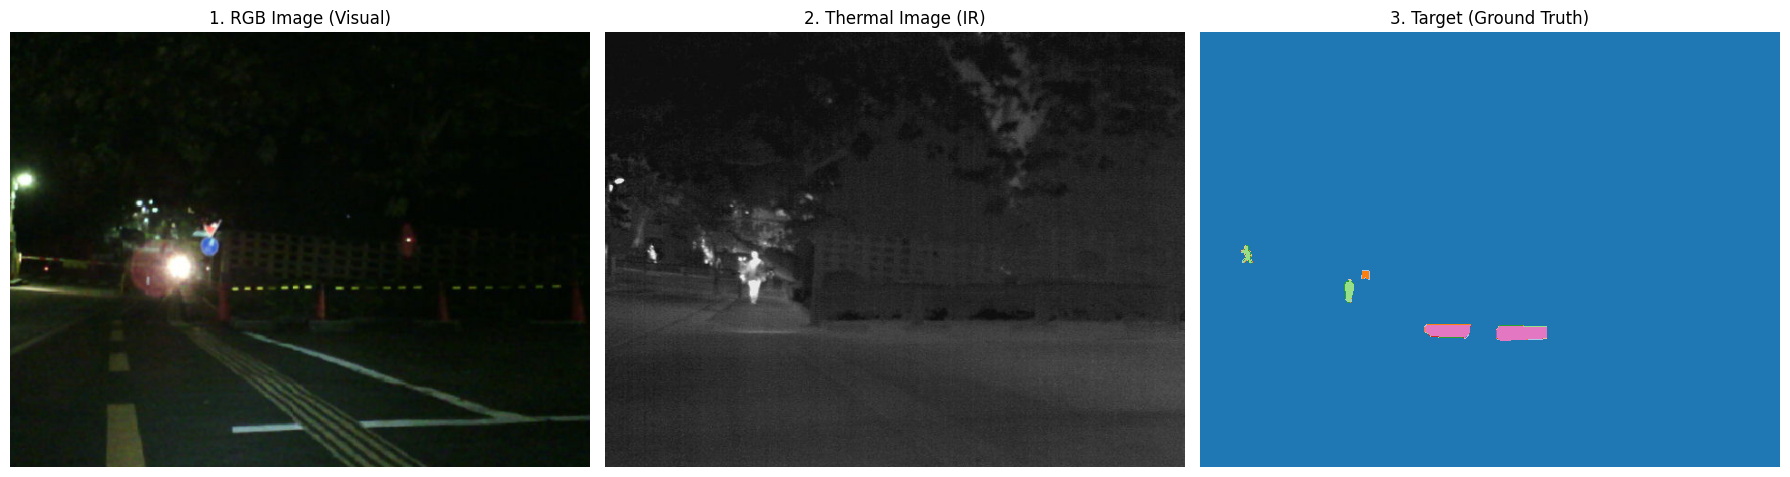

In [7]:
import matplotlib.pyplot as plt
import random
from torchvision import transforms
from sklearn.model_selection import train_test_split

img_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "labels")

immagini = {f.replace('.png', '') for f in os.listdir(img_dir) if f.endswith('.png')}
etichette = {f.replace('.png', '') for f in os.listdir(mask_dir) if f.endswith('.png')}

# We only keep files present in both sets
tutti_i_file = sorted(list(immagini.intersection(etichette)))

print(f"Found {len(tutti_i_file)} images.")

# We divide data into train and test sets (random_state is necessary if we have to resume training)
train_names, temp_names = train_test_split(tutti_i_file, test_size=0.2, random_state=42)
val_names, test_names = train_test_split(temp_names, test_size=0.5, random_state=42)

print(f"Division done: {len(train_names)} Train, {len(val_names)} Val, {len(test_names)} Test.")

# 3Initialize dataset
transform = transforms.ToTensor()

dataset_training = MFNetDataset(
    base_path=base_path,
    split_list=train_names,
    transform=transform,
    mode='train',
    drop_prob=0.2
)

dataset_val = MFNetDataset(
    base_path=base_path,
    split_list=val_names,
    transform=transform,
    mode='test',
    drop_prob=0.0            # No dropout on validation and test
)

dataset_test = MFNetDataset(
    base_path=base_path,
    split_list=test_names,
    transform=transform,
    mode='test',
    drop_prob=0.0
)

# Plot a random image
random_index = random.randint(0, len(dataset_training) - 1)
img_thermal, img_visual, true_mask = dataset_training[random_index]

# Prepare images for Matplotlib
img_t_plot = img_thermal.permute(1, 2, 0).numpy()
img_v_plot = img_visual.permute(1, 2, 0).numpy()
mask_plot = true_mask.numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# COLUMN 1: Visual Image (RGB)
axes[0].imshow(img_v_plot)
axes[0].set_title("1. RGB Image (Visual)")
axes[0].axis('off')

# COLUMN 2: Thermal Image
axes[1].imshow(img_t_plot)
axes[1].set_title("2. Thermal Image (IR)")
axes[1].axis('off')

# COLUMN 3: Target Mask
axes[2].imshow(mask_plot, cmap='tab20', vmin=0, vmax=8)
axes[2].set_title("3. Target (Ground Truth)")
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
"""
This cell shows differences between test images and augmented training images
"""


import matplotlib.pyplot as plt
from PIL import Image

num_esempi = 4
fig, axes = plt.subplots(num_esempi, 3, figsize=(15, 4 * num_esempi))

for i in range(num_esempi):

    idx = random.randint(0, len(dataset_training) - 1)

    base_name = dataset_training.common_names[idx]

    # Original file
    img_path = os.path.join(dataset_training.img_dir, base_name + ".png")
    img_originale = Image.open(img_path).convert('RGB')

    # Augmented one
    img_thermal, img_visual, true_mask = dataset_training[idx]

    img_v_plot = img_visual.permute(1, 2, 0).numpy()

    axes[i, 0].imshow(img_originale)
    axes[i, 0].set_title(f"Original (ID: {base_name})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_v_plot)
    axes[i, 1].set_title(f"AUGMENTED")
    axes[i, 1].axis('off')

    mask_plot = true_mask.numpy()
    axes[i, 2].imshow(mask_plot, cmap='tab20', vmin=0, vmax=8)
    axes[i, 2].set_title("Maschera Augmented")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

In [8]:
"""
In this cell we define the models that will be used in the projects.
They are inspired by the U-Net architecture
"""


import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x = self.conv_block(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super(UNet, self).__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down1 = DoubleConv(in_channels, 64)
        self.down2 = DoubleConv(64, 128)
        self.down3 = DoubleConv(128, 256)
        self.down4 = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)


    def forward(self, x):
        # ENCODER
        x1 = self.down1(x)
        p1 = self.pool(x1)

        x2 = self.down2(p1)
        p2 = self.pool(x2)

        x3 = self.down3(p2)
        p3 = self.pool(x3)

        x4 = self.down4(p3)
        p4 = self.pool(x4)

        b = self.bottleneck(p4)

        # DECODER

        u1 = self.up1(b)
        concat1 = torch.cat([x4, u1], dim=1)
        d1 = self.up_conv1(concat1)

        u2 = self.up2(d1)
        concat2 = torch.cat([x3, u2], dim=1)
        d2 = self.up_conv2(concat2)

        u3 = self.up3(d2)
        concat3 = torch.cat([x2, u3], dim=1)
        d3 = self.up_conv3(concat3)

        u4 = self.up4(d3)
        concat4 = torch.cat([x1, u4], dim=1)
        d4 = self.up_conv4(concat4)

        out = self.final_conv(d4)

        return out


class DualNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=9):
        super(DualNet, self).__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down1_rgb = DoubleConv(in_channels, 64)
        self.down2_rgb = DoubleConv(64, 128)
        self.down3_rgb = DoubleConv(128, 256)
        self.down4_rgb = DoubleConv(256, 512)

        self.down1_thermal = DoubleConv(in_channels, 64)
        self.down2_thermal = DoubleConv(64, 128)
        self.down3_thermal = DoubleConv(128, 256)
        self.down4_thermal = DoubleConv(256, 512)

        self.bottleneck = DoubleConv(1024, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = DoubleConv(1024, 512)

        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = DoubleConv(256, 128)

        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, num_classes, kernel_size=1)


    def forward(self, x_rgb, x_thermal):
        # ENCODER
        x1_rgb = self.down1_rgb(x_rgb)
        p1_rgb = self.pool(x1_rgb)

        x2_rgb = self.down2_rgb(p1_rgb)
        p2_rgb = self.pool(x2_rgb)

        x3_rgb = self.down3_rgb(p2_rgb)
        p3_rgb = self.pool(x3_rgb)

        x4_rgb = self.down4_rgb(p3_rgb)
        p4_rgb = self.pool(x4_rgb)

        x1_thermal = self.down1_thermal(x_thermal)
        p1_thermal = self.pool(x1_thermal)

        x2_thermal = self.down2_thermal(p1_thermal)
        p2_thermal = self.pool(x2_thermal)

        x3_thermal = self.down3_thermal(p2_thermal)
        p3_thermal = self.pool(x3_thermal)

        x4_thermal = self.down4_thermal(p3_thermal)
        p4_thermal = self.pool(x4_thermal)

        bn_input = torch.cat([p4_rgb, p4_thermal], dim=1)
        b = self.bottleneck(bn_input)

        skip4 = x4_rgb + x4_thermal
        skip3 = x3_rgb + x3_thermal
        skip2 = x2_rgb + x2_thermal
        skip1 = x1_rgb + x1_thermal

        # DECODER

        u1 = self.up1(b)
        concat1 = torch.cat([skip4, u1], dim=1)
        d1 = self.up_conv1(concat1)

        u2 = self.up2(d1)
        concat2 = torch.cat([skip3, u2], dim=1)
        d2 = self.up_conv2(concat2)

        u3 = self.up3(d2)
        concat3 = torch.cat([skip2, u3], dim=1)
        d3 = self.up_conv3(concat3)

        u4 = self.up4(d3)
        concat4 = torch.cat([skip1, u4], dim=1)
        d4 = self.up_conv4(concat4)

        out = self.final_conv(d4)

        return out

In [14]:
"""
In this cell the train function is defined. It promotes a modular approach for different models.
"""


import os
import torch
import torch.nn as nn
import torch.optim as optim

def train_model(modality, model, train_loader, val_loader, model_name,epochs=15, lr=0.0001, save_dir="/content/drive/MyDrive/3dPerceptionModels/modelli_salvati", resume_path=None):
    """
    Trains a deep learning model and saves the best performing checkpoints.

    Args:
        modality (str): The type of input data being processed (e.g., 'rgb', 'thermal', 'dual').
        model (torch.nn.Module): The neural network architecture to be trained.
        train_loader (torch.utils.data.DataLoader): The data loader providing the training dataset.
        val_loader (torch.utils.data.DataLoader): The data loader providing the validation dataset.
        model_name (str): A unique identifier for the model, used for naming saved files.
        epochs (int, optional): Total number of training iterations over the dataset. Defaults to 15.
        lr (float, optional): Learning rate for the optimizer. Defaults to 0.0001.
        save_dir (str, optional): Directory path where model checkpoints will be stored.
            Defaults to "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati".
        resume_path (str, optional): Path to a pre-existing checkpoint (.pth file) to resume
            training from a specific state. Defaults to None.

    Returns:
        model: The trained model, typically returning the version with the best validation performance.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\Strating training for {modality.upper()} on {device}")

    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    model = model.to(device)

    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{model_name}.pth")

    weights = torch.tensor([0.1, 1.5, 2.0, 2.0, 1.0, 1.0, 1.0, 1.5, 1.5]).to(device) #WCE
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    start_epoch = 0
    best_val_loss = float('inf')

    # Resume logic
    #---------------------------------------
    if resume_path and os.path.exists(resume_path):
        print(f"Checkpoint found! resume training from: {resume_path}")
        checkpoint = torch.load(resume_path)

        if isinstance(model, nn.DataParallel):
            model.module.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint['model_state_dict'])

        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        print(f"Resuming from epoch {start_epoch+1} Best validation loss so far: {best_val_loss:.4f}")
    #---------------------------------------

    for epoch in range(start_epoch, epochs):

        # Training
        model.train()
        train_loss = 0.0

        for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(train_loader):
            img_thermal, img_visual, true_mask = img_thermal.to(device), img_visual.to(device), true_mask.to(device)

            optimizer.zero_grad()

            if modality == 'rgb':
                predictions = model(img_visual)
            elif modality == 'thermal':
                predictions = model(img_thermal)
            elif modality == 'dual':
                predictions = model(img_visual, img_thermal)
            else:
                raise ValueError("La modalità deve essere 'rgb', 'thermal' o 'dual'")

            loss = criterion(predictions, true_mask)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for img_thermal, img_visual, true_mask in val_loader:
                img_thermal, img_visual, true_mask = img_thermal.to(device), img_visual.to(device), true_mask.to(device)

                if modality == 'rgb':
                    predictions = model(img_visual)
                elif modality == 'thermal':
                    predictions = model(img_thermal)
                elif modality == 'dual':
                    predictions = model(img_visual, img_thermal)

                loss = criterion(predictions, true_mask)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Checkpoint saving
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_loss': best_val_loss
            }
            torch.save(checkpoint, save_path)
            print(f"Model and optimizer saved on Drive -> {save_path}")

    print(f"Training of {modality.upper()} completed!\n")
    return model

In [ ]:
"""
This cell we train the different models
"""


from torch.utils.data import DataLoader

dataloader_train = DataLoader(dataset_training, batch_size=4, shuffle=True, num_workers=2)

dataloader_val = DataLoader(dataset_val, batch_size=4, shuffle=False, num_workers=2)
dataloader_test = DataLoader(dataset_test, batch_size=4, shuffle=False, num_workers=2)

# RGB
model_rgb = UNet(in_channels=3, num_classes=9)
train_model(
    modality='rgb',
    model=model_rgb,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    epochs=15,
    save_dir="../models"
)

# Thermal
model_thermal = UNet(in_channels=3, num_classes=9)
train_model(
    modality='thermal',
    model=model_thermal,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    epochs=15,
    save_dir="../models"
)

#Dual
model_dual = DualNet(in_channels=3, num_classes=9)
train_model(
    modality='dual',
    model=model_dual,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    epochs=15,
    save_dir="../models"
)

In [9]:
import torch
import numpy as np

def evaluate_late_fusion(model_rgb, model_thermal, test_loader, num_classes=9):
    """
    Evaluates a late fusion approach by combining predictions from RGB and Thermal models.
    Calculates the Mean Intersection over Union (mIoU) on the test dataset.

    Args:
        model_rgb (torch.nn.Module): The trained model for processing RGB modality.
        model_thermal (torch.nn.Module): The trained model for processing Thermal/Infrared modality.
        test_loader (torch.utils.data.DataLoader): DataLoader containing the test dataset samples.
        num_classes (int, optional): The number of semantic classes in the dataset for
            IoU calculation. Defaults to 9. 
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Starting validation...")

    model_rgb.eval()
    model_thermal.eval()

    metodi = [
        "RGB Only",
        "Thermal Only",
        "FUSION (Average)",
        "FUSION (Product)",
        "FUSION (Max)"
    ]

    intersezioni_globali = {m: np.zeros(num_classes) for m in metodi}
    unioni_globali = {m: np.zeros(num_classes) for m in metodi}

    with torch.no_grad():
        for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(test_loader):

            img_thermal = img_thermal.to(device)
            img_visual = img_visual.to(device)
            true_mask = true_mask.cpu().numpy()

            logits_rgb = model_rgb(img_visual)
            logits_thermal = model_thermal(img_thermal)

            prob_rgb = torch.softmax(logits_rgb, dim=1)
            prob_thermal = torch.softmax(logits_thermal, dim=1)

            preds = {}
            preds["RGB Only"] = torch.argmax(prob_rgb, dim=1).cpu().numpy()
            preds["Thermal Only"] = torch.argmax(prob_thermal, dim=1).cpu().numpy()
            preds["FUSION (Average)"] = torch.argmax((prob_rgb + prob_thermal) / 2.0, dim=1).cpu().numpy()
            preds["FUSION (Product)"] = torch.argmax(prob_rgb * prob_thermal, dim=1).cpu().numpy()
            preds["FUSION (Max)"] = torch.argmax(torch.max(prob_rgb, prob_thermal), dim=1).cpu().numpy()

            for m in metodi:
                pred_mask = preds[m]

                for c in range(num_classes):
                    pred_c = (pred_mask == c)
                    true_c = (true_mask == c)

                    intersezioni_globali[m][c] += np.logical_and(pred_c, true_c).sum()
                    unioni_globali[m][c] += np.logical_or(pred_c, true_c).sum()

    print("\n" + "="*50)
    print("Results:")
    print("="*50)

    for m in metodi:
        global_ious = []

        for c in range(num_classes):
            if unioni_globali[m][c] == 0:
                global_ious.append(np.nan)
            else:
                iou_c = intersezioni_globali[m][c] / unioni_globali[m][c]
                global_ious.append(iou_c)

        miou_finale = np.nanmean(global_ious)

        print(f"{m:18s} -> mIoU: {miou_finale:.4f}")

    print("="*50 + "\n")

In [ ]:
"""
This cell load models and calculate IoU
"""

import torch
from collections import OrderedDict
from torch.utils.data import DataLoader

def load_clean_state_dict(model, path, device):
    checkpoint = torch.load(path, map_location=device)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
        
    clean_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k.replace("module.", "") if k.startswith("module.") else k
        clean_state_dict[name] = v
        
    model.load_state_dict(clean_state_dict)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_rgb_test = UNet(in_channels=3, num_classes=9).to(device)
model_thermal_test = UNet(in_channels=3, num_classes=9).to(device)

# Define the paths
"""
percorso_rgb = "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/best_unet_rgb.pth"
percorso_thermal = "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/best_unet_thermal.pth"
"""

percorso_rgb = "../models/best_rgb.pth"
percorso_thermal = "../models/best_ir.pth"

print("Loading weights for RGB model...")
load_clean_state_dict(model_rgb_test, percorso_rgb, device)

print("Loading weights for thermal model...")
load_clean_state_dict(model_thermal_test, percorso_thermal, device)

print("Models loaded!")

evaluate_late_fusion(
    model_rgb=model_rgb_test,
    model_thermal=model_thermal_test,
    test_loader=dataloader_test,
    num_classes=9
)

Device: cpu


KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch

def evaluate_dualnet(model, test_loader, num_classes=9):
    """
    Performs a global evaluation of the DualNet model on the test set.

    This function calculates the Intersection over Union (IoU) for each class
    and the overall Mean IoU (mIoU) by processing paired Thermal and Visual
    inputs through the network.

    Args:
        model (torch.nn.Module): The DualNet model to evaluate. It must accept
            two input tensors (visual and thermal).
        test_loader (torch.utils.data.DataLoader): DataLoader yielding batches
            of (thermal_images, visual_images, ground_truth_masks).
        num_classes (int, optional): The number of semantic categories in the
            dataset. Defaults to 9.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Starting DualNet validation...")

    model.eval()

    intersections_np = np.zeros(num_classes)
    unions_np = np.zeros(num_classes)

    with torch.no_grad():
        for batch_idx, (img_thermal, img_visual, true_mask) in enumerate(test_loader):

            img_thermal = img_thermal.to(device)
            img_visual = img_visual.to(device)
            true_mask = true_mask.cpu().numpy()

            # Forward pass
            logits = model(img_visual, img_thermal)

            # Prediction
            pred_mask = torch.argmax(logits, dim=1).cpu().numpy()

            for c in range(num_classes):
                pred_c = (pred_mask == c)
                true_c = (true_mask == c)

                intersections_np[c] += np.logical_and(pred_c, true_c).sum()
                unions_np[c] += np.logical_or(pred_c, true_c).sum()

    print("\n" + "="*45)
    print("mIoU for Dualnet:")
    print("="*45)

    global_ious = []
    for c in range(num_classes):
        if unions_np[c] == 0:
            global_ious.append(np.nan)
            print(f"Class {c} not found")
        else:
            iou_c = intersections_np[c] / unions_np[c]
            global_ious.append(iou_c)
            print(f"Class {c}: {iou_c:.4f}")

    miou_finale = np.nanmean(global_ious)

    print("-" * 45)
    print(f"Global mIoU: {miou_finale:.4f}")
    print("-" * 45 + "\n")

In [ ]:
"""
This cell calculates the IoU for the DualNet Architecture
"""
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_dual_test = DualNet(in_channels=3, num_classes=9).to(device)

# Path
"""
percorso_dual = "/content/drive/MyDrive/modelli_salvati/best_model_dual.pth"
"""
percorso_dual = "../models/best_model_dual.pth"

print("Loading weights...")
try:
    checkpoint_dual = torch.load(percorso_dual, map_location=device)
    model_dual_test.load_state_dict(checkpoint_dual['model_state_dict'])
    print("Model loaded!")

    evaluate_dualnet(
        model=model_dual_test,
        test_loader=dataloader_test,
        num_classes=9
    )
except FileNotFoundError:
    print(f"Can't find weight on {percorso_dual}.")

In [ ]:
"""
We use models initialized with ImageNet weights to enhance feature extraction
capabilities and improve overall segmentation performance. This approach
allows for faster convergence and serves as a critical benchmark to compare
the effectiveness of Transfer Learning against models trained from scratch.
"""
from torch.utils.data import DataLoader
import segmentation_models_pytorch as smp

dataloader_train = DataLoader(dataset_training, batch_size=4, shuffle=True, num_workers=2)

dataloader_val = DataLoader(dataset_val, batch_size=4, shuffle=False, num_workers=2)
dataloader_test = DataLoader(dataset_test, batch_size=4, shuffle=False, num_workers=2)

# Pretrained RGB model
model_rgb_pretrained = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=9,
)

# Pretrained thermal model
model_thermal_pretrained = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=9,
    save_dir="../models"
)

# Training
train_model(
    modality='rgb',
    model=model_rgb_pretrained,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    model_name="smp_resnet34_rgb",
    epochs=15,
    save_dir="../models"
)

train_model(
    modality='thermal',
    model=model_thermal_pretrained,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    model_name="smp_resnet34_thermal",
    epochs=15,
    save_dir="../models"
)

In [ ]:
"""
Let's test the models trained with transfer learning
"""

import torch
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


model_rgb_test = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=9,
).to(device)

model_thermal_test = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=9,
).to(device)

"""
percorso_rgb = "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/smp_resnet34_rgb.pth"
percorso_thermal = "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/smp_resnet34_thermal.pth"
"""

percorso_rgb = "../models/smp_resnet34_rgb.pth"
percorso_thermal = "../models/smp_resnet34_thermal.pth"

print("Loading weights...")
checkpoint_rgb = torch.load(percorso_rgb, map_location=device)
model_rgb_test.load_state_dict(checkpoint_rgb['model_state_dict'])

checkpoint_thermal = torch.load(percorso_thermal, map_location=device)
model_thermal_test.load_state_dict(checkpoint_thermal['model_state_dict'])

print("Models loaded!")

evaluate_late_fusion(
    model_rgb=model_rgb_test,
    model_thermal=model_thermal_test,
    test_loader=dataloader_test,
    num_classes=9
)

In [ ]:
"""
In this cell we define a DualNet that uses pretrained models to fuse sensor data.
"""

import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

class DualNetPretrained(nn.Module):
    def __init__(self, num_classes=9):
        super(DualNetPretrained, self).__init__()

        self.encoder_rgb = smp.encoders.get_encoder("resnet34", in_channels=3, weights="imagenet")
        self.encoder_thermal = smp.encoders.get_encoder("resnet34", in_channels=3, weights="imagenet")

        dummy_unet = smp.Unet(encoder_name="resnet34", classes=num_classes)
        self.decoder = dummy_unet.decoder
        self.segmentation_head = dummy_unet.segmentation_head

    def forward(self, x_rgb, x_thermal):
        features_rgb = self.encoder_rgb(x_rgb)
        features_thermal = self.encoder_thermal(x_thermal)

        fused_features = []
        for f_rgb, f_th in zip(features_rgb, features_thermal):
            fused_features.append(f_rgb + f_th)

        decoder_output = self.decoder(fused_features)

        masks = self.segmentation_head(decoder_output)

        return masks



In [ ]:
# Let's train the DualNet pretrained model

dataloader_train = DataLoader(dataset_training, batch_size=4, shuffle=True, num_workers=2)

model_dual_pretrained = DualNetPretrained(num_classes=9)

train_model(
    modality='dual',
    model=model_dual_pretrained,
    train_loader=dataloader_train,
    val_loader=dataloader_val,
    model_name="smp_dualnet_pretrained_v1",
    epochs=15,
    save_dir="../models"
)

In [ ]:
# Test model performance

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_dual_test = DualNetPretrained(num_classes=9).to(device)

"""
percorso_dual = "/content/drive/MyDrive/3dPerceptionModels/modelli_salvati/smp_dualnet_pretrained_v1.pth"
""" 
percorso_dual = "../models/smp_dualnet_pretrained_v1.pth"

print(f"Loading weights from: {percorso_dual}")
try:
    checkpoint = torch.load(percorso_dual, map_location=device)
    model_dual_test.load_state_dict(checkpoint['model_state_dict'])

    evaluate_dualnet(
        model=model_dual_test,
        test_loader=dataloader_test,
        num_classes=9
    )
except FileNotFoundError:
    print("File not found")